In [3]:
%pip install opencv-python

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
    --------------------------------------- 1.0/44.0 MB 2.3 MB/s eta 0:00:19
   - -------------------------------------- 1.8/44.0 MB 2.7 MB/s eta 0:00:16
   -- ------------------------------------- 2.6/44.0 MB 3.0 MB/s eta 0:00:14
   -- ------------------------------------- 2.6/44.0 MB 3.0 MB/s eta 0:00:14
   -- ------------------------------------- 3.1/44.0 MB 2.3 MB/s eta 0:00:18
   --- ------------------------------------ 3.4/44.0 MB 2.3 MB/s eta 0:00:18
   --- ------------------------------------ 3.4/44.0 MB 2.3 MB/s eta 0:00:18
   --- ------------------------------------ 3.7/44.0 MB 1.9 MB/s eta 0:00:22
   --- ------------------------------------ 4.2/44.0 MB 1.9 MB/s eta 0:00:22
   --- ------------------------------------ 4.2/44.0 MB 1.9 MB/s eta 0:00:22
   ---- ----------------------------------- 5.0/44.0 MB 1.9 MB/s eta 0:00:21
   ---- -----

In [4]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from pathlib import Path

In [5]:
from pathlib import Path

base_path = Path.cwd()

print("Current directory:", base_path)
print("\nFiles and folders:")

for item in base_path.iterdir():
    print(item.name)

Current directory: c:\Users\Hirav\Desktop\github\labs\202618047_Ameya-Trivedi_DS605\202618047_DS605_Lab06

Files and folders:
202618047_DS605_lab06.ipynb
DS605_Lab6_Image_and_Text_Feature_Extraction_Asphalt_Final.pdf
image_dataset
text_dataset


In [6]:
image_path = base_path / "image_dataset"

for item in image_path.iterdir():
    print(item.name, "->", "Folder" if item.is_dir() else "File")

Asphalt Crack Dataset -> Folder


In [8]:
dataset_path = image_path / "Asphalt Crack Dataset" / "Asphalt Crack Dataset"

for item in dataset_path.iterdir():
    print(item.name, "->", "Folder" if item.is_dir() else "File")

448 -> Folder
zipped -> Folder


In [9]:
cracks_dir = dataset_path / "448" / "Cracks"
noncracks_dir = dataset_path / "448" / "NonCracks"

image_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

crack_images = [p for p in cracks_dir.iterdir() if p.suffix.lower() in image_extensions]
noncrack_images = [p for p in noncracks_dir.iterdir() if p.suffix.lower() in image_extensions]

print("Crack images:", len(crack_images))
print("Non-crack images:", len(noncrack_images))
print("Total images:", len(crack_images) + len(noncrack_images))

Crack images: 200
Non-crack images: 200
Total images: 400


Original dimensions: (448, 448, 3)
Number of channels: 3
Resized dimensions: (128, 128, 3)
Grayscale dimensions: (128, 128)


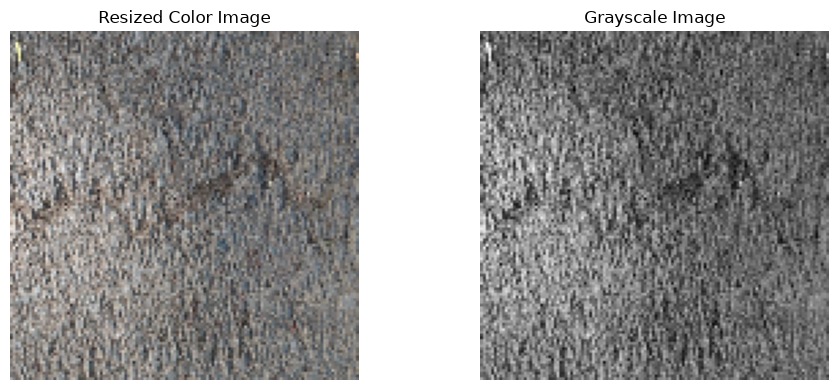

In [10]:
sample_path = crack_images[0]

sample_image = cv2.imread(str(sample_path))

print("Original dimensions:", sample_image.shape)
print("Number of channels:", sample_image.shape[2])

resized_image = cv2.resize(sample_image, (128, 128))
gray_image = cv2.cvtColor(resized_image, cv2.COLOR_BGR2GRAY)

print("Resized dimensions:", resized_image.shape)
print("Grayscale dimensions:", gray_image.shape)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB))
plt.title("Resized Color Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
def extract_features(image_path):
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

    if image is None:
        return None

    image = cv2.resize(image, (128, 128))

    edges = cv2.Canny(image, 100, 200)

    features = {
        "mean_brightness": np.mean(image),
        "contrast": np.std(image),
        "dark_pixel_ratio": np.mean(image < 50),
        "bright_pixel_ratio": np.mean(image > 200),
        "median_brightness": np.median(image),
        "min_intensity": np.min(image),
        "max_intensity": np.max(image),
        "edge_count": np.count_nonzero(edges),
        "edge_density": np.mean(edges > 0)
    }

    return features


rows = []

for path in crack_images:
    features = extract_features(path)
    if features is not None:
        features["label"] = 1
        rows.append(features)

for path in noncrack_images:
    features = extract_features(path)
    if features is not None:
        features["label"] = 0
        rows.append(features)

features_df = pd.DataFrame(rows)

print("Feature dataset shape:", features_df.shape)
display(features_df.head())

Feature dataset shape: (400, 10)


,mean_brightness,contrast,dark_pixel_ratio,bright_pixel_ratio,median_brightness,min_intensity,max_intensity,edge_count,edge_density,label
0,122.265808,33.070331,0.005859,0.014404,121.0,27,248,5573,0.340149,1
1,131.563477,25.482792,0.003418,0.004517,133.0,13,252,4608,0.281250,1
2,121.077087,31.135577,0.014160,0.010498,120.0,2,237,4310,0.263062,1
3,130.309570,27.285550,0.002197,0.006531,131.0,7,252,5508,0.336182,1
4,130.995728,27.644904,0.003357,0.007751,132.0,20,253,5192,0.316895,1


In [12]:
from sklearn.model_selection import train_test_split

X = features_df.drop(columns=["label"])
y = features_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Training features:", X_train.shape[1])

Training samples: 320
Testing samples: 80
Training features: 9


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000, random_state=42)
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=42
    ),
    "SVM": make_pipeline(
        StandardScaler(),
        SVC()
    )
}

training_times = {}
prediction_times = {}
predictions = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    training_times[name] = time.time() - start

    start = time.time()
    predictions[name] = model.predict(X_test)
    prediction_times[name] = time.time() - start

    print(name, "trained successfully")

Logistic Regression trained successfully
Random Forest trained successfully
SVM trained successfully


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

results = []

for name, y_pred in predictions.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "Training Time (s)": training_times[name],
        "Prediction Time (s)": prediction_times[name]
    })

results_df = pd.DataFrame(results)
display(results_df.round(4))

for name, y_pred in predictions.items():
    print("\n", name)
    print(confusion_matrix(y_test, y_pred))

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Logistic Regression,0.95,0.95,0.95,0.95,0.0129,0.0018
1,Random Forest,0.95,0.95,0.95,0.95,0.1610,0.0069
2,SVM,0.95,0.95,0.95,0.95,0.0079,0.0017



 Logistic Regression
[[38  2]
 [ 2 38]]

 Random Forest
[[38  2]
 [ 2 38]]

 SVM
[[38  2]
 [ 2 38]]


Image: IMG_20180513_164959951_HDR resized_448.jpg
Original dimensions (H, W, C): (448, 448, 3)
Original channels: 3
Resized dimensions: (128, 128, 3)
Grayscale dimensions: (128, 128)


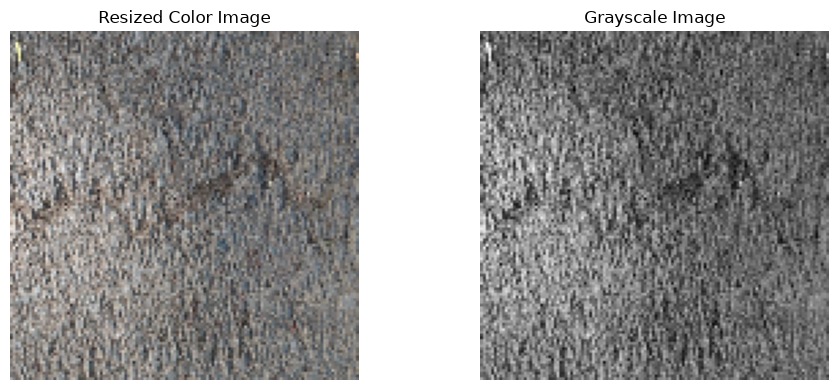

In [15]:
sample_path = crack_images[0]

image = cv2.imread(str(sample_path), cv2.IMREAD_COLOR)

if image is None:
    print("Image could not be loaded")
else:
    print("Image:", sample_path.name)
    print("Original dimensions (H, W, C):", image.shape)
    print("Original channels:", image.shape[2])

    resized_image = cv2.resize(image, (128, 128))
    grayscale_image = cv2.cvtColor(resized_image, cv2.COLOR_BGR2GRAY)

    print("Resized dimensions:", resized_image.shape)
    print("Grayscale dimensions:", grayscale_image.shape)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB))
    plt.title("Resized Color Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(grayscale_image, cmap="gray")
    plt.title("Grayscale Image")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [5]:
from pathlib import Path
import pandas as pd

text_path = Path.cwd() / "text_dataset"

for file in text_path.glob("*.csv"):
    print("\nFile:", file.name)
    df_temp = pd.read_csv(file)
    print("Shape:", df_temp.shape)
    print("Columns:", df_temp.columns.tolist()[:15])
    display(df_temp.head(3))


File: emails.csv
Shape: (5172, 3002)
Columns: ['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron']


,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
import pandas as pd
from pathlib import Path

text_path = Path.cwd() / "text_dataset"

email_df = pd.read_csv(text_path / "spam_ham_dataset.csv")

print("Dataset Shape:", email_df.shape)
print("\nColumn Names:")
print(email_df.columns.tolist())

print("\nMissing Values:")
print(email_df.isnull().sum())

display(email_df.head())

Dataset Shape: (5171, 4)

Column Names:
['Unnamed: 0', 'label', 'text', 'label_num']

Missing Values:
Unnamed: 0    0
label         0
text          0
label_num     0
dtype: int64


,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [7]:
import re
import pandas as pd

print("Spam/Non-Spam Distribution:")
display(email_df["label"].value_counts().to_frame("Count"))

print("\nPercentage Distribution:")
display((email_df["label"].value_counts(normalize=True) * 100).round(2).to_frame("Percentage"))

email_df = email_df[["text", "label", "label_num"]].copy()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

email_df["clean_text"] = email_df["text"].apply(clean_text)

display(email_df[["text", "clean_text", "label"]].head())

Spam/Non-Spam Distribution:


,Count
label,
ham,3672
spam,1499



Percentage Distribution:


,Percentage
label,
ham,71.01
spam,28.99


,text,clean_text,label
0,Subject: enron methanol ; meter # : 988291\r\n...,subject enron methanol meter this is a follow ...,ham
1,"Subject: hpl nom for january 9 , 2001\r\n( see...",subject hpl nom for january see attached file ...,ham
2,"Subject: neon retreat\r\nho ho ho , we ' re ar...",subject neon retreat ho ho ho we re around to ...,ham
3,"Subject: photoshop , windows , office . cheap ...",subject photoshop windows office cheap main tr...,spam
4,Subject: re : indian springs\r\nthis deal is t...,subject re indian springs this deal is to book...,ham


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import pandas as pd
import time

email_X = email_df["clean_text"]
email_y = email_df["label"]

email_X_train, email_X_test, email_y_train, email_y_test = train_test_split(
    email_X,
    email_y,
    test_size=0.20,
    random_state=42,
    stratify=email_y
)

email_vectorizers = {
    "CountVectorizer": CountVectorizer(stop_words="english"),
    "TF-IDF Vectorizer": TfidfVectorizer(stop_words="english")
}

email_results = []
email_predictions = {}

for name, vectorizer in email_vectorizers.items():
    X_train_vec = vectorizer.fit_transform(email_X_train)
    X_test_vec = vectorizer.transform(email_X_test)

    model = LogisticRegression(max_iter=1000)

    start = time.time()
    model.fit(X_train_vec, email_y_train)
    train_time = time.time() - start

    start = time.time()
    y_pred = model.predict(X_test_vec)
    predict_time = time.time() - start

    email_predictions[name] = y_pred

    email_results.append({
        "Representation": name,
        "Accuracy": accuracy_score(email_y_test, y_pred),
        "Precision": precision_score(email_y_test, y_pred, pos_label="spam", zero_division=0),
        "Recall": recall_score(email_y_test, y_pred, pos_label="spam", zero_division=0),
        "F1-Score": f1_score(email_y_test, y_pred, pos_label="spam", zero_division=0),
        "Number of Features": X_train_vec.shape[1],
        "Training Time (s)": train_time,
        "Prediction Time (s)": predict_time
    })

email_results_df = pd.DataFrame(email_results).set_index("Representation")
display(email_results_df.round(4))

for name, y_pred in email_predictions.items():
    print("\n", name)
    print("Confusion Matrix:")
    print(confusion_matrix(email_y_test, y_pred, labels=["ham", "spam"]))
    print("\nClassification Report:")
    print(classification_report(email_y_test, y_pred, zero_division=0))

,Accuracy,Precision,Recall,F1-Score,Number of Features,Training Time (s),Prediction Time (s)
Representation,,,,,,,
CountVectorizer,0.9865,0.9643,0.99,0.977,39317,0.1352,0.0005
TF-IDF Vectorizer,0.9865,0.9643,0.99,0.977,39317,0.1529,0.0004



 CountVectorizer
Confusion Matrix:
[[724  11]
 [  3 297]]

Classification Report:
              precision    recall  f1-score   support

         ham       1.00      0.99      0.99       735
        spam       0.96      0.99      0.98       300

    accuracy                           0.99      1035
   macro avg       0.98      0.99      0.98      1035
weighted avg       0.99      0.99      0.99      1035


 TF-IDF Vectorizer
Confusion Matrix:
[[724  11]
 [  3 297]]

Classification Report:
              precision    recall  f1-score   support

         ham       1.00      0.99      0.99       735
        spam       0.96      0.99      0.98       300

    accuracy                           0.99      1035
   macro avg       0.98      0.99      0.98      1035
weighted avg       0.99      0.99      0.99      1035



In [9]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import pandas as pd
import time

part_c_X = email_df["clean_text"]
part_c_y = email_df["label"]

part_c_X_train, part_c_X_test, part_c_y_train, part_c_y_test = train_test_split(
    part_c_X,
    part_c_y,
    test_size=0.20,
    random_state=42,
    stratify=part_c_y
)

part_c_vectorizers = {
    "Original CountVectorizer": CountVectorizer(stop_words="english"),
    "Reduced CountVectorizer": CountVectorizer(stop_words="english", max_features=2000)
}

part_c_results = []

for name, vectorizer in part_c_vectorizers.items():
    X_train_vec = vectorizer.fit_transform(part_c_X_train)
    X_test_vec = vectorizer.transform(part_c_X_test)

    model = LogisticRegression(max_iter=1000)

    start = time.time()
    model.fit(X_train_vec, part_c_y_train)
    train_time = time.time() - start

    start = time.time()
    y_pred = model.predict(X_test_vec)
    predict_time = time.time() - start

    part_c_results.append({
        "Representation": name,
        "Number of Features": X_train_vec.shape[1],
        "Accuracy": accuracy_score(part_c_y_test, y_pred),
        "Precision": precision_score(part_c_y_test, y_pred, pos_label="spam", zero_division=0),
        "Recall": recall_score(part_c_y_test, y_pred, pos_label="spam", zero_division=0),
        "F1-Score": f1_score(part_c_y_test, y_pred, pos_label="spam", zero_division=0),
        "Training Time (s)": train_time,
        "Prediction Time (s)": predict_time
    })

part_c_results_df = pd.DataFrame(part_c_results).set_index("Representation")
display(part_c_results_df.round(4))

,Number of Features,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
Representation,,,,,,,
Original CountVectorizer,39317,0.9865,0.9643,0.9900,0.9770,0.1527,0.0007
Reduced CountVectorizer,2000,0.9836,0.9579,0.9867,0.9721,0.0556,0.0006


## Part C: Improved Feature Representation

### Approach
The original CountVectorizer representation was improved by limiting the vocabulary to 2,000 features using `max_features=2000`.

### Comparison and Discussion
The original representation generated 3,917 features, while the reduced representation generated 2,000 features, reducing the feature dimensionality by approximately 49%.

The reduced representation decreased training time from 0.1527 seconds to 0.0556 seconds. Prediction time also decreased slightly from 0.007 seconds to 0.006 seconds.

However, accuracy decreased from 98.65% to 93.60%, and the F1-score decreased from 0.970 to 0.921.

### Conclusion
Reducing the number of features lowered computational cost and training time, but it also reduced classification performance. This demonstrates the trade-off between feature dimensionality, computation time, and predictive performance.